# Tutorial 4: Linear Regression

Linear regression is a technique used to find the `linear` relationship between one or more explanatory (independent and dependent) variables and a single scalar (dependant) variable. Simple linear regression is when there is only one explanatory variable. In this tutorial we will be focusing on solving a simple linear regression problem using two methods:
1. Using a closed-form solution using matirx algebra
2. Iterative optimzation of a function

It is important to note that the techniuques introduced in this tutorial can be applied to the multiple or multivaraible linear regression where there are more than one explanatory variable.

# Setup
Firstly, we'll be generating some toy data to better visualise the problem and algorithms. To easily visualize the data, we will create a set of 2D data points.

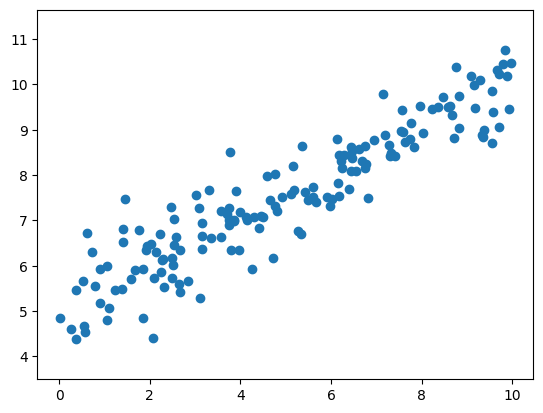

In [1]:
# Creating a toy dataset of n_points
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split # TO split data into a train and test set

n_points = 200 # Number of points in the dataset
test_size = 0.2 # Propotion of the test split

x = 10*np.random.rand(n_points, 1) # Uniformly generate n_points in between [0,10]
y = 0.5*x + 5 + 0.6*np.random.randn(n_points, 1) # Points are normally distributed around y=0.5x + 0.6 line

# split the dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=test_size, random_state=42)

# Let's plot the points using the scatter function
plt.scatter(x_train, y_train)
plt.axis('equal')
plt.show()

# Formulation

Given a dataset of $\{\mathbf{x}_i, y_i\}_{i=1}^n$ of $n$ points, where each point is described by an explanatory variable of a $d$-dimension vector $\mathbf{x}_i$ and its scalar response is $y_i$, a linear relationship can be written as follows:
$$
y_i = w_0 + w_1 {x}_{i,1} + \dots + w_d {x}_{i,d}  + {\epsilon} \\
y_i = \mathbf{x}_i^T \mathbf{w} + \epsilon
$$
The variable $\epsilon$ is an unobserved random variable known as the disturbance term or error variable which adds noise to the linear relationship.
The variable $\mathbf{w}$ describes the weights of the linear relationship $[w_0, w_1, \dots, w_d]^T$.
To simplify notation, the bias term $w_0$ is often included with the other weights by increasing the dimension of $\mathbf{x}_i$, setting $x_{i,0} = 1$.
Thus, $\mathbf{x}_i = [1, x_{i,1}, \dots, x_{i,d}]^T$.

Using matrix notation the linear relationship for the entire dataset can be written as:
$$
\mathbf{y} = \mathbf{X} \mathbf{w} + \mathbf{\epsilon}
$$
where $\mathbf{y} = [y_1, \dots, y_n]^T$,
$\mathbf{X} = [\mathbf{x_1},\dots,\mathbf{x_n}]^T$ and $\boldsymbol\epsilon = [\epsilon_1,\dots,\epsilon_n]^T$.


In [2]:
# Creating matrices
y = y_train
x1 = np.concatenate((x_train, np.ones((x_train.shape[0],1))), axis=-1)

print(f'Shape of y is {y.shape}.')
print(f'Shape of x1 is {x1.shape}.')

Shape of y is (160, 1).
Shape of x1 is (160, 2).


## Closed Form Solution

We wish to find the model ($\mathbf{w}^*$) that minimises the *mean squared error* (MSE). The optimal values $\mathbf{w}^*$ are obtained:
$$
\begin{aligned}
  \mathbf{w}^*
  &= \min_{\mathbf{w}} \frac1n\sum_{i=1}^n \epsilon_i^2
  \\
  &= \min_{\mathbf{w}} \frac1n ||\boldsymbol\epsilon||^2
  \\
% &= \min_{\mathbf{w}} \frac1n\sum_{i=1}^n ( y_i - \mathbf{x}_i^T \mathbf{w} )^2
% \\
  &= \min_{\mathbf{w}} \frac1n || \mathbf{y} - \mathbf{X} \mathbf{w} ||^2
\end{aligned}
$$
Crutially, this optimisation has a *closed form solution* using matrix algebra:
$$
\mathbf{w}^* = ( \mathbf{X}^T \, \mathbf{X} )^{-1} \, \mathbf{X}^T \, \mathbf{y}
$$
You can reach this conclusion yourself by calculating the gradient of the error with respect to the minimisation variable $\mathbf{w}$, and setting the gradient to zero.

> Calculate the optimal value of model weights $\mathbf{w}$. Use matrix multiplication `@` and matrix inversion `inv` from `numpy.linalg`.

In [3]:
from numpy.linalg import inv
# Get the weight based on matrix algebra
#w = (XT . X)^-1 . XT y
w = inv(x1.T @ x1)@(x1.T@y)

print(w)

[[0.49679595]
 [5.04623051]]


Visualise the model you have just created.

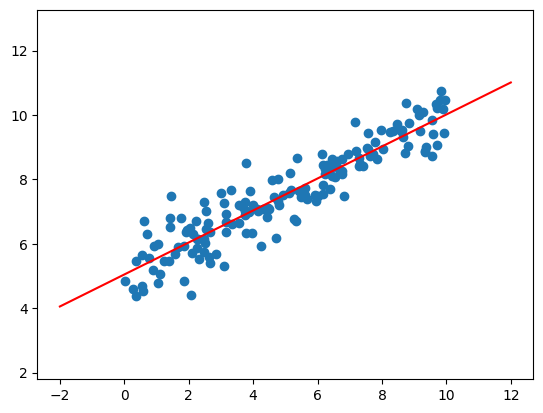

In [4]:
# Let's plot the points using the scatter function
plot_points = 100

x_line = np.linspace(-2, 12, plot_points)[:,None]
x1_line = np.concatenate((x_line, np.ones((plot_points, 1))), axis=-1)

y_line = x1_line @ w

plt.scatter(x_train, y_train)
plt.plot(x1_line[:,0], y_line, '-r')
plt.axis('equal')
plt.show()

Mean Squared Error is 0.30269130046089954


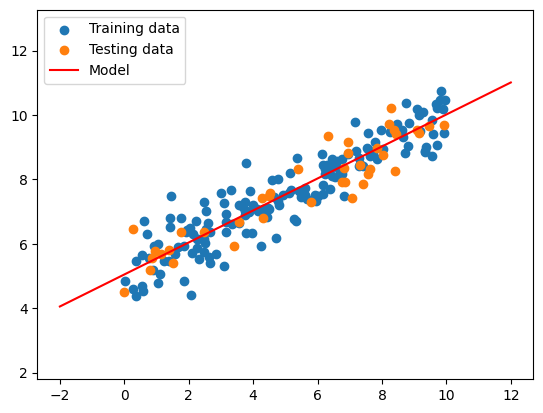

In [5]:
## Test on the test set
x1_test = np.concatenate((x_test, np.ones((x_test.shape[0],1))), axis=-1)
y_test = np.asarray(y_test)

from sklearn.metrics import mean_squared_error

y_pred = x1_test @ w  # TODO
y_mse = mean_squared_error(y_pred, y_test)  # TODO
print(f'Mean Squared Error is {y_mse}')

## Show with test data
plt.scatter(x_train, y_train)
plt.scatter(x_test, y_test)
plt.plot(x1_line[:,0], y_line, '-r')
plt.legend(['Training data', 'Testing data', 'Model'])
plt.axis('equal')
plt.show()

## Optimization using Gradient Descent

We create the same model using the `pytorch` library. Creating a model in this way allows for the automatic calculation of gradients, and training of the model using gradient descent.

> The definition and training of the model has been largely implemented for you, read through the implementation and fill in some missing parameters.
> *Note: you will need to implement more complicated models in future tutorials.*

> After training, evaluate the model on the test data.

In [6]:
import torch
import torch.nn as nn

# Define the neural network model
class LinearRegression(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        # This is equivalent to: input @ weight + bias
        # with weight of shape [input_dim, output_dim]
        # and bias of shape [output_dim]
        self.linear = nn.Linear(input_dim, output_dim, bias=True)

    # this is the method called when you evaluate the model
    def forward(self, input):
        output = self.linear(input)
        return output

# Define the hyperparameters
input_dim = 1  # TODO
output_dim = 1  # TODO
learning_rate = 0.005
num_epochs = 3000

# Convert the data to PyTorch tensors
x_train = torch.as_tensor(x_train).float()
y_train = torch.as_tensor(y_train).float()
x_test = torch.as_tensor(x_test).float()
y_test = torch.as_tensor(y_test).float()

# Create an instance of the LinearRegression model
model = LinearRegression(input_dim, output_dim)

# Define the loss function and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

# Train the model
for epoch in range(num_epochs):
    # Forward pass
    y_pred = model(x_train)  # evaluate the model
    loss = criterion(y_pred, y_train)  # calculate the loss

    # Backward and optimize
    optimizer.zero_grad()  # clears any stored gradients
    loss.backward()  # calculates gradients with respect to the loss
    optimizer.step()  # updates the model parameters

    # print progress
    if (epoch+1) % 100 == 0:
        print(f"Epoch [{epoch+1:4d}/{num_epochs}], training loss: {loss.item():.4f}")

# Evaluate the model on the test data
with torch.no_grad():  # so not to calculate gradients while evaluating #Wrap your evaluation loop in a torch.no_grad() block. This is important as it disables gradient computation, which saves memory and speeds up computation during evaluation.
    y_pred = model(x_test)
    test_mse = criterion(y_pred, y_test)  # TODO
    print(f"Test loss: {test_mse:.4f}")

Epoch [ 100/3000], training loss: 3.4370
Epoch [ 200/3000], training loss: 2.2672
Epoch [ 300/3000], training loss: 1.5378
Epoch [ 400/3000], training loss: 1.0830
Epoch [ 500/3000], training loss: 0.7994
Epoch [ 600/3000], training loss: 0.6225
Epoch [ 700/3000], training loss: 0.5123
Epoch [ 800/3000], training loss: 0.4435
Epoch [ 900/3000], training loss: 0.4006
Epoch [1000/3000], training loss: 0.3739
Epoch [1100/3000], training loss: 0.3572
Epoch [1200/3000], training loss: 0.3468
Epoch [1300/3000], training loss: 0.3403
Epoch [1400/3000], training loss: 0.3363
Epoch [1500/3000], training loss: 0.3338
Epoch [1600/3000], training loss: 0.3322
Epoch [1700/3000], training loss: 0.3312
Epoch [1800/3000], training loss: 0.3306
Epoch [1900/3000], training loss: 0.3302
Epoch [2000/3000], training loss: 0.3300
Epoch [2100/3000], training loss: 0.3298
Epoch [2200/3000], training loss: 0.3298
Epoch [2300/3000], training loss: 0.3297
Epoch [2400/3000], training loss: 0.3297
Epoch [2500/3000

Visualise both models.

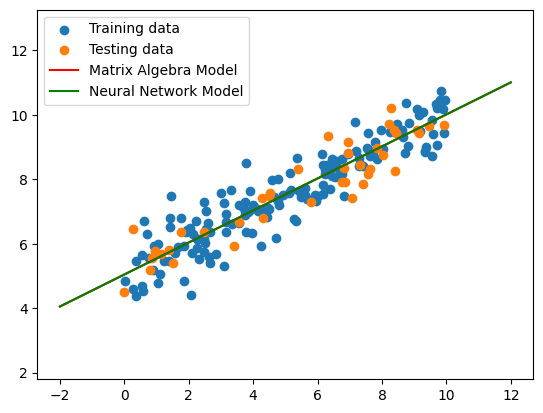

Parameter 'linear.weight' is tensor([[0.4974]])
Parameter 'linear.bias' is tensor([5.0424])


In [7]:
# Let's plot the points using the scatter function
x_line = torch.as_tensor(x_line).float()
with torch.no_grad():
    y_line_nn = model(x_line)

plt.scatter(x_train, y_train)  # training data
plt.scatter(x_test, y_test)  # test data
plt.plot(x_line[:,0], y_line, '-r')  # matrix algebra model
plt.plot(x_line[:,0], y_line_nn[:, 0], '-g')  # gradient descent model
plt.legend(['Training data', 'Testing data', 'Matrix Algebra Model', 'Neural Network Model'])
plt.axis('equal')
plt.show()

# See the learnt model values
for name, param in model.named_parameters():
    print(f"Parameter '{name}' is {param.data}")

## Comparison

As the model is linear, there is a closed form solution using matrix operations.

However, the gradient descent training method is applicable to any model where gradients can be calculated. Internally, The `torch` library successfully calculates gradients for a wide number of operations, and propogates the gradients through to the model parameters using the chain rule.

> Compare the performance of both models on the test set.
> What happens to the model trained by gradient descent if the number of iterations is reduced?